[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


=== HASIL FREKUENSI KATA SLANG ===
        Kata  Frekuensi
3     banget          4
9        fyp          4
1      video          2
0     bestie          2
11   flexing          2
4    healing          2
7      spill          2
2      keren          1
6        sih          1
5         ga          1
8     tempat          1
10       nih          1
12       bro          1
13    cantik          1
14    pantai          1
15      enak          1
16  skincare          1
17       nya          1
18       kak          1
19     motor          1


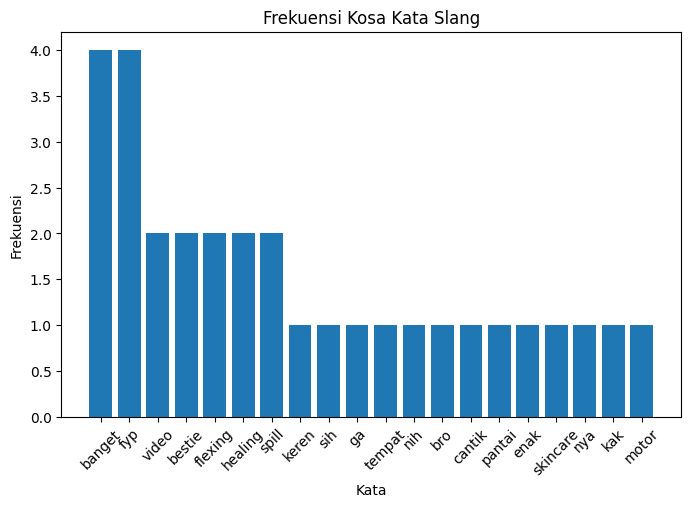

In [ ]:
# ==========================================
# ANALISIS FREKUENSI KOSA KATA SLANG
# ==========================================

# INSTALL LIBRARY
!pip install Sastrawi nltk wordcloud -q

# IMPORT LIBRARY
import pandas as pd
import re
import nltk
import matplotlib.pyplot as plt

from collections import Counter
from nltk.corpus import stopwords
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

# DOWNLOAD DATA NLTK
nltk.download('stopwords')

# ==========================================
# DATA KOMENTAR
# ==========================================

komentar = [
    "bestie video ini keren banget",
    "healing dulu ga sih",
    "spill dong tempatnya",
    "fyp terus nih video",
    "flexing banget bro",
    "bestieee cantik banget",
    "healing ke pantai enak banget",
    "spill skincare nya kak",
    "fyp fyp fyp",
    "flexing motor baru"
]

# ==========================================
# CLEANING TEXT
# ==========================================

def cleaning(teks):
    teks = teks.lower()
    teks = re.sub(r"http\S+", "", teks)
    teks = re.sub(r"[^a-zA-Z\s]", "", teks)
    teks = re.sub(r"\s+", " ", teks).strip()
    return teks

clean_comments = [cleaning(k) for k in komentar]

# ==========================================
# TOKENIZING
# ==========================================

tokens = []

for kalimat in clean_comments:
    kata = kalimat.split()
    tokens.extend(kata)

# ==========================================
# STOPWORD REMOVAL
# ==========================================

stop_words = set(stopwords.words('indonesian'))

filtered_tokens = [
    kata for kata in tokens
    if kata not in stop_words
]

# ==========================================
# STEMMING
# ==========================================

factory = StemmerFactory()
stemmer = factory.create_stemmer()

hasil_stemming = [
    stemmer.stem(kata)
    for kata in filtered_tokens
]

# ==========================================
# NORMALISASI KATA
# ==========================================

normalisasi = {
    "bestieee": "bestie"
}

hasil_normalisasi = []

for kata in hasil_stemming:
    if kata in normalisasi:
        hasil_normalisasi.append(normalisasi[kata])
    else:
        hasil_normalisasi.append(kata)

# ==========================================
# HITUNG FREKUENSI
# ==========================================

frekuensi = Counter(hasil_normalisasi)

# ==========================================
# DATAFRAME
# ==========================================

df = pd.DataFrame(
    frekuensi.items(),
    columns=["Kata", "Frekuensi"]
)

# URUTKAN DATA
df = df.sort_values(
    by="Frekuensi",
    ascending=False
)

# ==========================================
# TAMPILKAN HASIL
# ==========================================

print("=== HASIL FREKUENSI KATA SLANG ===")
print(df)

# ==========================================
# VISUALISASI GRAFIK
# ==========================================

plt.figure(figsize=(8,5))

plt.bar(
    df["Kata"],
    df["Frekuensi"]
)

plt.title("Frekuensi Kosa Kata Slang")
plt.xlabel("Kata")
plt.ylabel("Frekuensi")

plt.xticks(rotation=45)

plt.show()